In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df = pd.read_csv(
    r'C:\Users\boser\Desktop\Project_Carbon\data\processed\final_dataset_engineered.csv',
    index_col='date',
    parse_dates=True
)

df = df.sort_index()
print("Shape:", df.shape)
print("Date range:", df.index.min(), "→", df.index.max())

Shape: (577, 15)
Date range: 2015-04-05 00:00:00 → 2026-04-26 00:00:00


In [2]:
# WHY: From EDA, gas_price_weekly and gas_price_lag1 have VIF ~19 and
# correlation of 0.848 with each other. Including both in a model causes
# multicollinearity — the model cannot distinguish their individual effects
# and coefficient estimates become unstable. We keep gas_price_lag1 because
# it is more theoretically justified: we're predicting THIS week's change
# using LAST week's gas price. gas_price_weekly is contemporaneous — 
# in a real deployment you wouldn't have it at prediction time anyway.

# co2_ppm is also excluded — VIF of 12.8 and it's a trend variable, not a shock variable.

TARGET = 'carbon_price_change_pct'

FEATURES = [
    'gas_price_lag1',        # Lagged gas price — theoretically clean
    'gas_price_volatility',  # Energy shock intensity
    'vix',                   # Market fear
    'co2_change',            # Weekly atmospheric signal
    'days_to_next_cop',      # COP calendar effect
    'cop_urgency',           # Non-linear COP proximity score
    'is_cop_week',           # Binary summit flag
    'recent_volatility',     # Carbon market's own momentum risk
    'momentum_4w',           # Short-term price momentum
    'momentum_12w',          # Medium-term price momentum
    'regime'                 # Structural break indicator (0/1/2)
]

X = df[FEATURES]
y = df[TARGET]

print("Features used:", len(FEATURES))
print(X.shape)

Features used: 11
(577, 11)


In [3]:
# WHY: You NEVER randomly shuffle time series data. Random splitting would
# let the model train on 2023 data and test on 2020 data — it has seen
# the future. This is data leakage and produces fraudulent metrics.
#
# The correct approach: train on everything up to a cutoff date,
# test on everything after. This simulates real deployment exactly —
# you train on historical data, then predict on data you've never seen.
#
# We use 2023-01-01 as the cutoff. This gives:
# - Train: 2015-2022 (the dormant + awakening + energy crisis regimes)
# - Test : 2023-2026 (the mature high-price regime)
# This is the hardest possible test — the test set is the most recent
# and structurally different period.

SPLIT_DATE = '2023-01-01'

X_train = X[X.index <  SPLIT_DATE]
X_test  = X[X.index >= SPLIT_DATE]
y_train = y[y.index <  SPLIT_DATE]
y_test  = y[y.index >= SPLIT_DATE]

print(f"Train: {X_train.shape} | {X_train.index.min().date()} → {X_train.index.max().date()}")
print(f"Test : {X_test.shape}  | {X_test.index.min().date()} → {X_test.index.max().date()}")
print(f"Train size: {len(X_train)/len(X)*100:.1f}% | Test size: {len(X_test)/len(X)*100:.1f}%")

Train: (404, 11) | 2015-04-05 → 2022-12-25
Test : (173, 11)  | 2023-01-01 → 2026-04-26
Train size: 70.0% | Test size: 30.0%


In [4]:
# WHY: Tree models (Random Forest, XGBoost) don't need scaling — they
# split on thresholds, not distances. But Ridge and Lasso DO need it —
# they penalise coefficients and if gas_price_lag1 is in range 1-14
# but co2_change is in range -0.5 to 0.8, the model will unfairly
# penalise the larger-scale feature more.
#
# CRITICAL RULE: Fit the scaler on TRAIN data only. Then transform both
# train and test using the train statistics. If you fit on the full
# dataset, you're leaking test set statistics (mean, std) into training.
# That's subtle data leakage and it inflates metrics.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)         # transform only on test

# Convert back to DataFrames for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURES, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=FEATURES, index=X_test.index)

print("Scaling done. Train mean (should be ~0):", X_train_scaled.mean().round(3).values)

Scaling done. Train mean (should be ~0): [-0.  0.  0.  0.  0. -0.  0.  0.  0.  0. -0.]


In [5]:
# WHY we use Directional Accuracy:
# R² and RMSE measure magnitude of error. But for a carbon trader,
# what matters is: did I predict the DIRECTION correctly?
# If carbon went up and you predicted up, you make money — even if
# the magnitude was wrong. Directional accuracy (sign accuracy) is
# the most practically relevant metric for financial prediction.

def evaluate(name, y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Directional accuracy: did we get the sign right?
    direction_correct = np.mean(np.sign(y_pred) == np.sign(y_true)) * 100

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  R²                   : {r2:.4f}")
    print(f"  MAE                  : {mae:.4f}%")
    print(f"  RMSE                 : {rmse:.4f}%")
    print(f"  Directional Accuracy : {direction_correct:.1f}%")
    
    return {'Model': name, 'R²': r2, 'MAE': mae, 'RMSE': rmse, 'Dir Acc': direction_correct}

results = []

In [6]:
# WHY: Before any real model, you need a baseline — the dumbest possible
# prediction strategy. DummyRegressor(strategy='mean') just predicts
# the mean of the training target every single time (0.57%).
#
# This is your benchmark. If your fancy XGBoost can't beat predicting
# 0.57% every week, it is useless. R² of a mean predictor is exactly 0
# by definition — it explains 0% of variance. Any model that beats 0 R²
# is at least learning something.

dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train_scaled, y_train)
y_pred_dummy = dummy.predict(X_test_scaled)

results.append(evaluate("Baseline (Mean Predictor)", y_test, y_pred_dummy))


  Baseline (Mean Predictor)
  R²                   : -0.0308
  MAE                  : 3.5101%
  RMSE                 : 4.4979%
  Directional Accuracy : 49.1%


In [7]:
# WHY Ridge over plain OLS:
# Ridge adds an L2 penalty (sum of squared coefficients) to the loss function.
# This shrinks large coefficients toward zero — it handles multicollinearity
# gracefully by distributing weight across correlated features rather than
# assigning all weight to one arbitrarily.
#
# WHY TimeSeriesSplit for cross-validation:
# We cannot use KFold because it shuffles data. TimeSeriesSplit creates
# sequential folds: fold 1 trains on weeks 1-100 and validates on 101-150,
# fold 2 trains on 1-150 validates on 151-200, and so on. This respects
# the temporal order and gives you a realistic estimate of out-of-sample
# performance without leaking future data into training.

from sklearn.model_selection import GridSearchCV

tscv = TimeSeriesSplit(n_splits=5)

ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100, 1000]}
ridge_cv = GridSearchCV(Ridge(), ridge_params, cv=tscv, scoring='r2', refit=True)
ridge_cv.fit(X_train_scaled, y_train)

print(f"Best Ridge alpha: {ridge_cv.best_params_['alpha']}")
print(f"Best CV R²: {ridge_cv.best_score_:.4f}")

y_pred_ridge = ridge_cv.predict(X_test_scaled)
results.append(evaluate("Ridge Regression", y_test, y_pred_ridge))

Best Ridge alpha: 100
Best CV R²: 0.1381

  Ridge Regression
  R²                   : 0.1654
  MAE                  : 3.1227%
  RMSE                 : 4.0473%
  Directional Accuracy : 59.5%


In [8]:
# WHY Lasso:
# Lasso adds an L1 penalty (sum of absolute coefficients). Unlike Ridge,
# Lasso can shrink coefficients all the way to ZERO — it performs automatic
# feature selection. Features that genuinely don't help get eliminated.
# This is useful here because we suspect most of our features have very
# weak signal (confirmed by EDA R² near zero).
# If Lasso zeroes out most features, that's an important finding.

lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
lasso_cv = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=tscv, scoring='r2', refit=True)
lasso_cv.fit(X_train_scaled, y_train)

print(f"Best Lasso alpha: {lasso_cv.best_params_['alpha']}")
print(f"Best CV R²: {lasso_cv.best_score_:.4f}")

# Show which features Lasso kept vs eliminated
lasso_coefs = pd.Series(lasso_cv.best_estimator_.coef_, index=FEATURES)
print("\nLasso Coefficients (0 = eliminated):")
print(lasso_coefs.sort_values(key=abs, ascending=False).round(4))

y_pred_lasso = lasso_cv.predict(X_test_scaled)
results.append(evaluate("Lasso Regression", y_test, y_pred_lasso))

Best Lasso alpha: 0.1
Best CV R²: 0.1483

Lasso Coefficients (0 = eliminated):
momentum_4w             2.5210
momentum_12w            0.5056
is_cop_week            -0.3555
vix                     0.1692
recent_volatility       0.0916
cop_urgency             0.0386
co2_change              0.0297
gas_price_volatility   -0.0287
regime                 -0.0265
gas_price_lag1          0.0000
days_to_next_cop       -0.0000
dtype: float64

  Lasso Regression
  R²                   : 0.1927
  MAE                  : 3.0500%
  RMSE                 : 3.9806%
  Directional Accuracy : 61.8%


In [9]:
# WHY Random Forest:
# From EDA, the relationships are non-linear and interaction-based.
# For example, the gas price → carbon price relationship may only activate
# during a specific regime AND when VIX is low. A linear model cannot
# detect this — it needs a feature explicitly created for that interaction.
# Random Forest can discover these interactions automatically by splitting
# on multiple features in sequence.
#
# Random Forest also gives you feature importance — which tells you which
# features the model actually relied on, giving you insight into the
# underlying market structure.
#
# n_estimators=500: more trees = more stable estimates. 
# max_depth=5: shallow trees prevent overfitting on 577 rows.
# min_samples_leaf=20: each leaf node must have at least 20 observations.
#   This is critical — with 577 rows, a deep tree will memorise noise.
# random_state=42: reproducibility.

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=20,
    max_features='sqrt',   # At each split, consider sqrt(n_features) — reduces overfitting
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
results.append(evaluate("Random Forest", y_test, y_pred_rf))

# Feature Importance
fi_rf = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("\nRandom Forest Feature Importance:")
print(fi_rf.round(4))


  Random Forest
  R²                   : 0.1428
  MAE                  : 3.2322%
  RMSE                 : 4.1018%
  Directional Accuracy : 60.7%

Random Forest Feature Importance:
momentum_4w             0.4500
momentum_12w            0.2270
gas_price_volatility    0.0646
recent_volatility       0.0620
gas_price_lag1          0.0562
vix                     0.0439
co2_change              0.0436
days_to_next_cop        0.0409
regime                  0.0103
cop_urgency             0.0014
is_cop_week             0.0000
dtype: float64


In [10]:
# WHY XGBoost:
# XGBoost (Extreme Gradient Boosting) builds trees sequentially — each
# new tree corrects the errors of all previous trees. This is different
# from Random Forest where trees are built independently and averaged.
# Boosting tends to find more subtle patterns but is more prone to
# overfitting, especially on small datasets.
#
# Key parameters for a 577-row dataset:
# n_estimators=300: number of boosting rounds
# max_depth=3: very shallow — with 577 rows, depth 3 is already ~8 leaf nodes
# learning_rate=0.05: small steps — each tree contributes only 5%
# subsample=0.8: train each tree on 80% of rows — reduces overfitting
# colsample_bytree=0.8: use 80% of features per tree — reduces overfitting
# early_stopping_rounds: stop if validation score doesn't improve for 30 rounds
#   This prevents overfitting automatically.

from sklearn.model_selection import train_test_split

# For early stopping, XGBoost needs a validation set
# We take the last 20% of training data as internal validation
# (chronologically — NOT random)
val_cutoff = int(len(X_train_scaled) * 0.8)
X_tr  = X_train_scaled.iloc[:val_cutoff]
X_val = X_train_scaled.iloc[val_cutoff:]
y_tr  = y_train.iloc[:val_cutoff]
y_val = y_train.iloc[val_cutoff:]

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,         # L1 regularisation — equivalent to Lasso penalty inside XGBoost
    reg_lambda=1.0,        # L2 regularisation — equivalent to Ridge penalty inside XGBoost
    random_state=42,
    eval_metric='rmse',
    early_stopping_rounds=30,
    verbosity=0
)

xgb.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f"XGBoost stopped at round: {xgb.best_iteration}")

y_pred_xgb = xgb.predict(X_test_scaled)
results.append(evaluate("XGBoost", y_test, y_pred_xgb))

# Feature Importance
fi_xgb = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("\nXGBoost Feature Importance:")
print(fi_xgb.round(4))

XGBoost stopped at round: 193

  XGBoost
  R²                   : 0.0167
  MAE                  : 3.4362%
  RMSE                 : 4.3930%
  Directional Accuracy : 56.1%

XGBoost Feature Importance:
momentum_4w             0.2162
recent_volatility       0.1054
momentum_12w            0.0992
gas_price_volatility    0.0880
is_cop_week             0.0831
vix                     0.0816
co2_change              0.0751
gas_price_lag1          0.0731
cop_urgency             0.0627
days_to_next_cop        0.0605
regime                  0.0551
dtype: float32


In [11]:
results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.sort_values('R²', ascending=False)

print("\n" + "="*70)
print("FULL MODEL COMPARISON")
print("="*70)
print(results_df.round(4).to_string())


FULL MODEL COMPARISON
                               R²     MAE    RMSE  Dir Acc
Model                                                     
Lasso Regression           0.1927  3.0500  3.9806  61.8497
Ridge Regression           0.1654  3.1227  4.0473  59.5376
Random Forest              0.1428  3.2322  4.1018  60.6936
XGBoost                    0.0167  3.4362  4.3930  56.0694
Baseline (Mean Predictor) -0.0308  3.5101  4.4979  49.1329


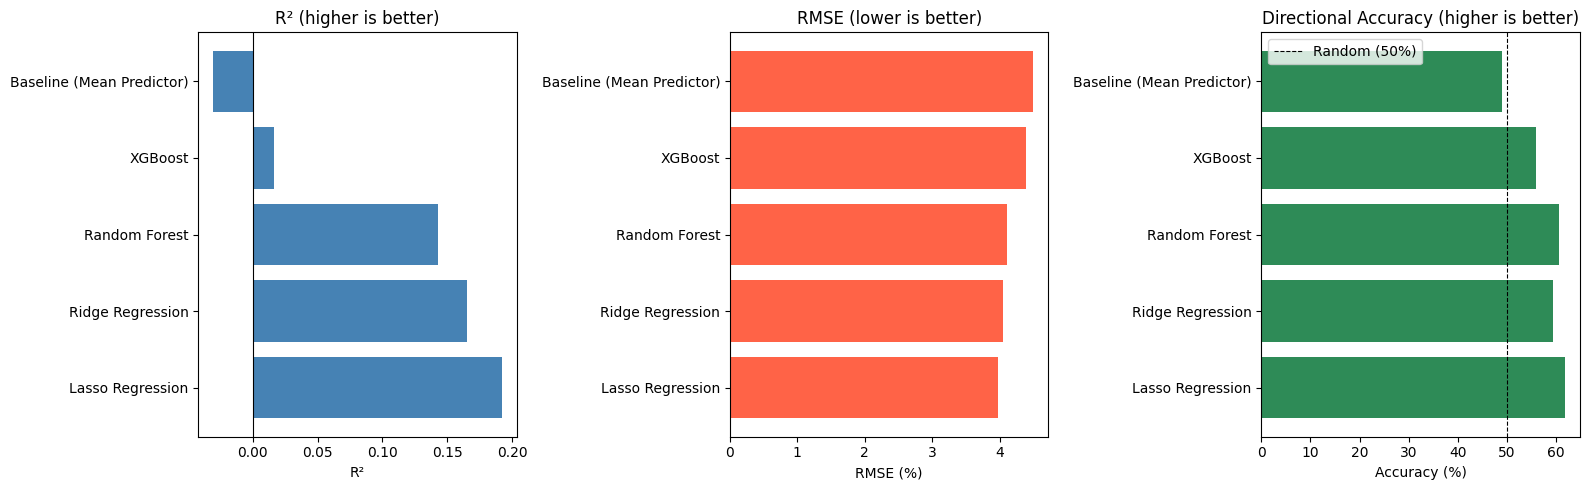

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# R² comparison
axes[0].barh(results_df.index, results_df['R²'], color='steelblue')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('R² (higher is better)')
axes[0].set_xlabel('R²')

# RMSE comparison
axes[1].barh(results_df.index, results_df['RMSE'], color='tomato')
axes[1].set_title('RMSE (lower is better)')
axes[1].set_xlabel('RMSE (%)')

# Directional Accuracy
axes[2].barh(results_df.index, results_df['Dir Acc'], color='seagreen')
axes[2].axvline(50, color='black', linewidth=0.8, linestyle='--', label='Random (50%)')
axes[2].set_title('Directional Accuracy (higher is better)')
axes[2].set_xlabel('Accuracy (%)')
axes[2].legend()

plt.tight_layout()
plt.show()

Best model: Lasso Regression


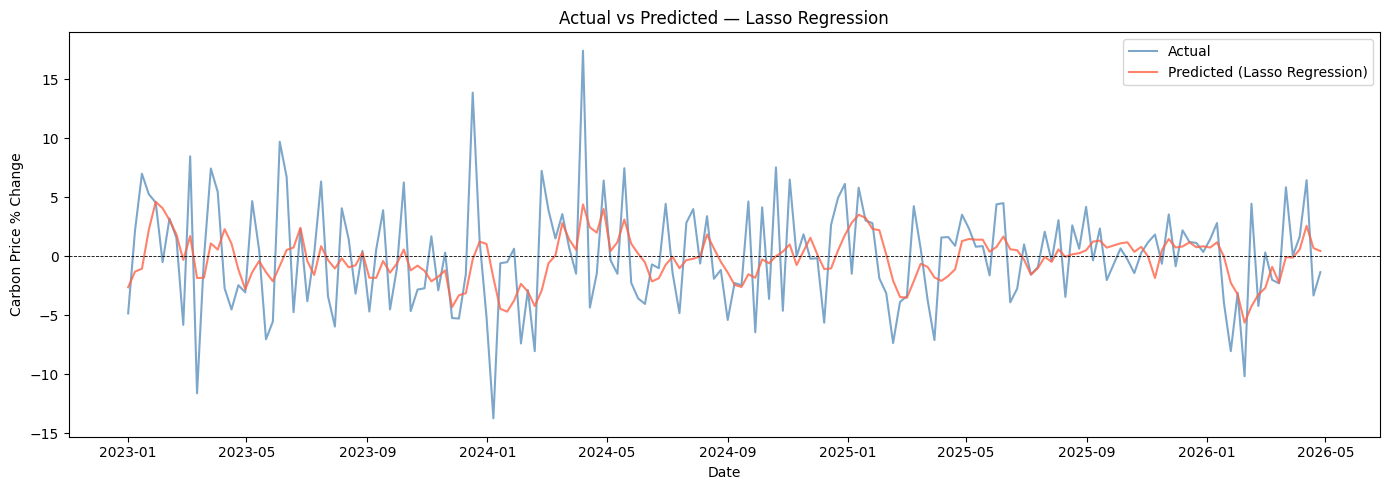

In [13]:
# Run this after you know which model performed best
# Replace y_pred_best with whichever model won

best_model_name = results_df.index[0]
print(f"Best model: {best_model_name}")

# Map name to predictions
pred_map = {
    'Baseline (Mean Predictor)': y_pred_dummy,
    'Ridge Regression'         : y_pred_ridge,
    'Lasso Regression'         : y_pred_lasso,
    'Random Forest'            : y_pred_rf,
    'XGBoost'                  : y_pred_xgb
}

y_pred_best = pred_map[best_model_name]

plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test.values, color='steelblue', alpha=0.7, label='Actual')
plt.plot(y_test.index, y_pred_best,   color='tomato',    alpha=0.8, label=f'Predicted ({best_model_name})')
plt.axhline(0, color='black', linewidth=0.6, linestyle='--')
plt.title(f'Actual vs Predicted — {best_model_name}')
plt.xlabel('Date')
plt.ylabel('Carbon Price % Change')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# WHY this matters:
# A model with overall R² = 0.05 might have R² = 0.15 in regime 2
# and R² = -0.02 in regime 0. That tells you the model only works
# during high-price, high-volatility periods. That's a crucial finding
# for deployment — you'd only trust it in certain market conditions.

test_df = pd.DataFrame({
    'actual'   : y_test.values,
    'predicted': y_pred_best,
    'regime'   : df.loc[y_test.index, 'regime'].values
}, index=y_test.index)

print("\nPerformance by Market Regime:")
print("-" * 55)
for regime_val, label in [(1, 'Regime 1: Policy Reform (2018-2020)'),
                           (2, 'Regime 2: High Price Era (2021-2026)')]:
    subset = test_df[test_df['regime'] == regime_val]
    if len(subset) > 10:
        r2_r  = r2_score(subset['actual'], subset['predicted'])
        dir_r = np.mean(np.sign(subset['predicted']) == np.sign(subset['actual'])) * 100
        print(f"\n{label} (n={len(subset)})")
        print(f"  R²                   : {r2_r:.4f}")
        print(f"  Directional Accuracy : {dir_r:.1f}%")


Performance by Market Regime:
-------------------------------------------------------

Regime 2: High Price Era (2021-2026) (n=173)
  R²                   : 0.1927
  Directional Accuracy : 61.8%


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df = pd.read_csv(
    r'C:\Users\boser\Desktop\Project_Carbon\data\processed\final_dataset_engineered.csv',
    index_col='date',
    parse_dates=True
).sort_index()

TARGET = 'carbon_price_change_pct'
FEATURES = [
    'gas_price_lag1', 'gas_price_volatility', 'vix', 'co2_change',
    'days_to_next_cop', 'cop_urgency', 'is_cop_week',
    'recent_volatility', 'momentum_4w', 'momentum_12w', 'regime'
]

df = df.dropna(subset=FEATURES + [TARGET])

SPLIT_DATE = '2023-01-01'
X_train = df.loc[df.index <  SPLIT_DATE, FEATURES]
X_test  = df.loc[df.index >= SPLIT_DATE, FEATURES]
y_train = df.loc[df.index <  SPLIT_DATE, TARGET]
y_test  = df.loc[df.index >= SPLIT_DATE, TARGET]

scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURES, index=X_train.index)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=FEATURES, index=X_test.index)

# TimeSeriesSplit — same CV strategy throughout
tscv = TimeSeriesSplit(n_splits=5)

def evaluate(name, y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    dir_acc = np.mean(np.sign(y_pred) == np.sign(y_true)) * 100
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  R²                   : {r2:.4f}")
    print(f"  MAE                  : {mae:.4f}%")
    print(f"  RMSE                 : {rmse:.4f}%")
    print(f"  Directional Accuracy : {dir_acc:.1f}%")
    return {'Model': name, 'R²': r2, 'MAE': mae, 'RMSE': rmse, 'Dir Acc': dir_acc}

results_tuned = []

In [18]:
# ── RIDGE — Hyperparameter Tuning ──────────────────────────────────────────
# WHY wider search: the current best is alpha=100. We need to search both
# sides of that heavily to confirm it's truly optimal. The range 0.01 to
# 10000 covers 6 orders of magnitude — standard practice for regularisation.

ridge_params = {'alpha': [0.01, 0.1, 1, 10, 50, 100, 200, 500, 1000, 5000, 10000]}

ridge_cv = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=tscv,
    scoring='r2',
    refit=True,
    n_jobs=-1
)
ridge_cv.fit(X_train_sc, y_train)

print(f"Best Ridge alpha : {ridge_cv.best_params_['alpha']}")
print(f"Best CV R²       : {ridge_cv.best_score_:.4f}")

y_pred_ridge = ridge_cv.predict(X_test_sc)
results_tuned.append(evaluate("Ridge (Tuned)", y_test, y_pred_ridge))

Best Ridge alpha : 50
Best CV R²       : 0.1474

  Ridge (Tuned)
  R²                   : 0.1531
  MAE                  : 3.1383%
  RMSE                 : 4.0771%
  Directional Accuracy : 60.7%


In [20]:
# ── LASSO — Hyperparameter Tuning ──────────────────────────────────────────
# WHY: Current best alpha=0.1. Lasso is sensitive to alpha — too small
# and it behaves like OLS, too large and it zeros everything out.
# We search a fine grid around 0.1 plus wider extremes to be sure.
# max_iter=50000: Lasso uses coordinate descent which can be slow
# to converge when alpha is very small — increase iterations to ensure
# convergence and avoid warnings.

lasso_params = {'alpha': [0.001, 0.005, 0.01, 0.05, 0.08, 0.1, 0.15, 0.2, 0.5, 1.0, 5.0]}

lasso_cv = GridSearchCV(
    Lasso(max_iter=50000),
    lasso_params,
    cv=tscv,
    scoring='r2',
    refit=True,
    n_jobs=-1
)
lasso_cv.fit(X_train_sc, y_train)

print(f"Best Lasso alpha : {lasso_cv.best_params_['alpha']}")
print(f"Best CV R²       : {lasso_cv.best_score_:.4f}")

# Show final coefficients — which features survived tuning?
lasso_coefs = pd.Series(lasso_cv.best_estimator_.coef_, index=FEATURES)
print("\nLasso Coefficients after tuning (0 = eliminated):")
print(lasso_coefs.sort_values(key=abs, ascending=False).round(4))

y_pred_lasso = lasso_cv.predict(X_test_sc)
results_tuned.append(evaluate("Lasso (Tuned)", y_test, y_pred_lasso))

Best Lasso alpha : 0.2
Best CV R²       : 0.1696

Lasso Coefficients after tuning (0 = eliminated):
momentum_4w             2.4500
momentum_12w            0.4075
is_cop_week            -0.2379
vix                     0.0526
recent_volatility       0.0027
gas_price_volatility   -0.0000
gas_price_lag1          0.0000
cop_urgency             0.0000
days_to_next_cop       -0.0000
co2_change              0.0000
regime                 -0.0000
dtype: float64

  Lasso (Tuned)
  R²                   : 0.1934
  MAE                  : 3.0642%
  RMSE                 : 3.9789%
  Directional Accuracy : 62.4%


In [23]:
# ── RANDOM FOREST — Hyperparameter Tuning ──────────────────────────────────
# WHY Random Forest is underperforming (R²=0.14 vs Lasso 0.19):
# The default settings (max_depth=5, min_samples_leaf=20) may be either
# too restrictive OR not restrictive enough. With 404 training rows,
# we need to search aggressively for the right complexity level.
#
# Key parameters being tuned:
#
# n_estimators: More trees = more stable. 200-1000 is the useful range.
#   Beyond 1000, diminishing returns. We include it to confirm stability.
#
# max_depth: Controls how deep each tree grows.
#   Shallow (3-4): underfits, misses real patterns.
#   Deep (8+): overfits on 404 rows.
#   We search 3 to 8 plus None (unlimited — likely overfits here).
#
# min_samples_leaf: Minimum observations at each leaf node.
#   Higher value = simpler trees = less overfitting.
#   With 404 rows, you want this high. Range 10-40.
#
# max_features: How many features to consider at each split.
#   'sqrt' = 3 features out of 11. Lower = more randomness = less overfitting.
#   We also try 0.5 (5-6 features) and 0.3 (3 features).
#
# WHY RandomizedSearchCV here:
#   6×5×4×3 = 360 combinations × 5 folds = 1800 fits.
#   RandomizedSearchCV with n_iter=60 does 300 fits — 6x faster.
#   Research shows n_iter=50-100 finds optimal solutions as reliably
#   as full grid search in continuous/large parameter spaces.

from scipy.stats import randint, uniform

rf_param_dist = {
    'n_estimators'    : [200, 300, 500, 700, 1000],
    'max_depth'       : [3, 4, 5, 6, 7, 8, None],
    'min_samples_leaf': [5, 10, 15, 20, 25, 30, 40],
    'max_features'    : ['sqrt', 0.3, 0.4, 0.5, 0.6, 0.7],
    'min_samples_split': [5, 10, 15, 20]
}

rf_random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=80,          # 80 random combinations — thorough but fast
    cv=tscv,
    scoring='r2',
    refit=True,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf_random.fit(X_train_sc, y_train)

print(f"\nBest RF parameters:")
for k, v in rf_random.best_params_.items():
    print(f"  {k}: {v}")
print(f"Best CV R²: {rf_random.best_score_:.4f}")

y_pred_rf = rf_random.predict(X_test_sc)
results_tuned.append(evaluate("Random Forest (Tuned)", y_test, y_pred_rf))

# Feature importance from tuned model
fi_rf = pd.Series(rf_random.best_estimator_.feature_importances_, index=FEATURES)
print("\nRandom Forest Feature Importance (Tuned):")
print(fi_rf.sort_values(ascending=False).round(4))

Fitting 5 folds for each of 80 candidates, totalling 400 fits

Best RF parameters:
  n_estimators: 500
  min_samples_split: 15
  min_samples_leaf: 5
  max_features: 0.6
  max_depth: 8
Best CV R²: 0.1289

  Random Forest (Tuned)
  R²                   : 0.1311
  MAE                  : 3.3002%
  RMSE                 : 4.1297%
  Directional Accuracy : 60.7%

Random Forest Feature Importance (Tuned):
momentum_4w             0.4392
momentum_12w            0.1656
recent_volatility       0.1226
gas_price_volatility    0.0766
vix                     0.0525
co2_change              0.0508
gas_price_lag1          0.0454
days_to_next_cop        0.0378
regime                  0.0061
cop_urgency             0.0032
is_cop_week             0.0003
dtype: float64


In [24]:
# ── XGBOOST — Hyperparameter Tuning ──────────────────────────────────────
# WHY XGBoost performed so badly (R²=0.016):
# Early stopping at round 193 with learning_rate=0.05 means it built
# a complex model with many boosting rounds. With only 404 training rows,
# this is almost certainly overfitting — the model memorised training
# noise that doesn't exist in the 2023-2026 test period.
#
# The fix is to search toward SIMPLER, MORE REGULARISED configurations:
#
# max_depth=2: Almost always better than 3+ for small tabular datasets.
#   A depth-2 tree has 4 leaves — it only captures pair-wise interactions.
#   That's often enough when signal is weak.
#
# learning_rate: Smaller = more trees needed but better generalisation.
#   We search 0.005 to 0.1. Combined with n_estimators, this controls
#   the effective model capacity.
#
# n_estimators: We remove early stopping in RandomizedSearchCV because
#   it complicates the CV loop. Instead we fix n_estimators and rely on
#   reg_alpha/reg_lambda to control overfitting.
#
# reg_alpha (L1): XGBoost's equivalent of Lasso. High values zero out
#   weak feature contributions. Since Lasso outperformed, this matters.
#
# reg_lambda (L2): XGBoost's equivalent of Ridge. Default is 1.
#   Higher values shrink all weights — reduces overfitting.
#
# subsample + colsample_bytree: Stochastic gradient boosting.
#   Using 60-80% of rows and features per tree introduces randomness
#   that prevents overfitting — like Dropout in neural networks.
#
# min_child_weight: Minimum sum of instance weights in a leaf.
#   Higher = more conservative splits = less overfitting.
#   With 404 rows, try 5-20.

xgb_param_dist = {
    'n_estimators'     : [100, 150, 200, 300, 400, 500],
    'max_depth'        : [2, 3, 4, 5],
    'learning_rate'    : [0.005, 0.01, 0.02, 0.05, 0.08, 0.1],
    'subsample'        : [0.5, 0.6, 0.7, 0.8, 0.9],
    'colsample_bytree' : [0.4, 0.5, 0.6, 0.7, 0.8],
    'reg_alpha'        : [0, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
    'reg_lambda'       : [0.5, 1.0, 2.0, 5.0, 10.0, 20.0],
    'min_child_weight' : [1, 3, 5, 10, 15, 20],
    'gamma'            : [0, 0.1, 0.5, 1.0, 2.0]
    # gamma: Minimum loss reduction required to make a split.
    # Positive gamma makes the algorithm more conservative.
    # Very useful for noisy, small datasets.
}

xgb_random = RandomizedSearchCV(
    XGBRegressor(random_state=42, verbosity=0, eval_metric='rmse'),
    param_distributions=xgb_param_dist,
    n_iter=80,
    cv=tscv,
    scoring='r2',
    refit=True,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
xgb_random.fit(X_train_sc, y_train)

print(f"\nBest XGBoost parameters:")
for k, v in xgb_random.best_params_.items():
    print(f"  {k}: {v}")
print(f"Best CV R²: {xgb_random.best_score_:.4f}")

y_pred_xgb = xgb_random.predict(X_test_sc)
results_tuned.append(evaluate("XGBoost (Tuned)", y_test, y_pred_xgb))

fi_xgb = pd.Series(xgb_random.best_estimator_.feature_importances_, index=FEATURES)
print("\nXGBoost Feature Importance (Tuned):")
print(fi_xgb.sort_values(ascending=False).round(4))

Fitting 5 folds for each of 80 candidates, totalling 400 fits

Best XGBoost parameters:
  subsample: 0.9
  reg_lambda: 1.0
  reg_alpha: 2.0
  n_estimators: 400
  min_child_weight: 3
  max_depth: 3
  learning_rate: 0.005
  gamma: 1.0
  colsample_bytree: 0.7
Best CV R²: 0.1239

  XGBoost (Tuned)
  R²                   : 0.1600
  MAE                  : 3.2556%
  RMSE                 : 4.0604%
  Directional Accuracy : 63.0%

XGBoost Feature Importance (Tuned):
momentum_4w             0.2454
momentum_12w            0.1458
recent_volatility       0.1048
gas_price_volatility    0.0934
vix                     0.0778
gas_price_lag1          0.0764
cop_urgency             0.0756
days_to_next_cop        0.0740
co2_change              0.0605
regime                  0.0464
is_cop_week             0.0000
dtype: float32


In [25]:
# ── FULL COMPARISON TABLE ──────────────────────────────────────────────────

# Add baseline for reference
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train_sc, y_train)
y_pred_dummy = dummy.predict(X_test_sc)
results_tuned.append(evaluate("Baseline", y_test, y_pred_dummy))

results_df = pd.DataFrame(results_tuned).set_index('Model')
results_df = results_df.sort_values('R²', ascending=False)

print("\n" + "="*65)
print("TUNED MODEL COMPARISON")
print("="*65)
print(results_df.round(4).to_string())


  Baseline
  R²                   : -0.0308
  MAE                  : 3.5101%
  RMSE                 : 4.4979%
  Directional Accuracy : 49.1%

TUNED MODEL COMPARISON
                           R²     MAE    RMSE  Dir Acc
Model                                                 
Lasso (Tuned)          0.1934  3.0642  3.9789  62.4277
XGBoost (Tuned)        0.1600  3.2556  4.0604  63.0058
Ridge (Tuned)          0.1531  3.1383  4.0771  60.6936
Ridge (Tuned)          0.1531  3.1383  4.0771  60.6936
Random Forest (Tuned)  0.1311  3.3002  4.1297  60.6936
Baseline              -0.0308  3.5101  4.4979  49.1329


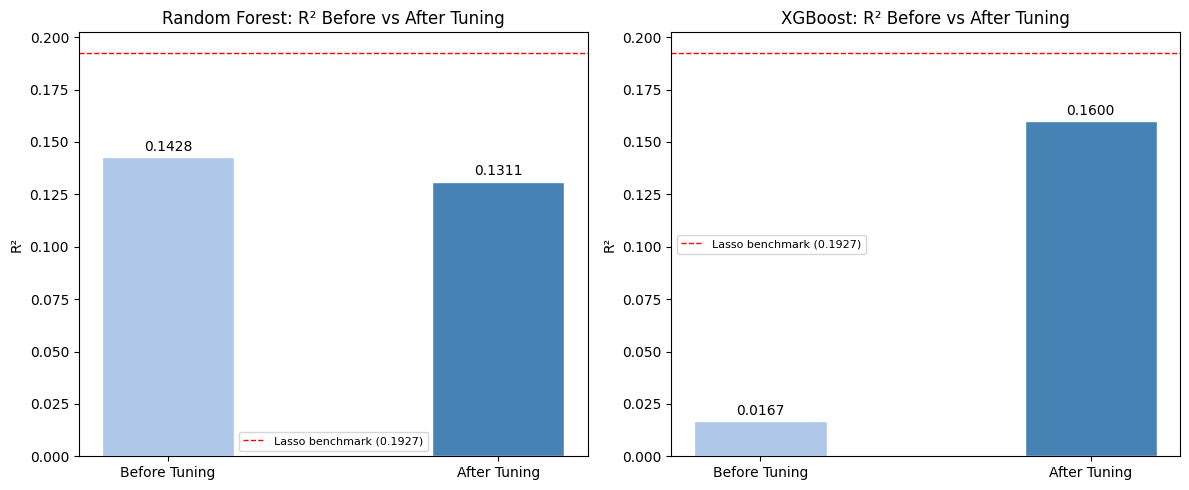

In [26]:
# ── VISUALISE TUNING IMPROVEMENT ──────────────────────────────────────────
# Compare pre-tuning vs post-tuning for RF and XGBoost specifically

before = {'Random Forest': 0.1428, 'XGBoost': 0.0167}
after  = {
    'Random Forest': results_df.loc['Random Forest (Tuned)', 'R²'],
    'XGBoost'      : results_df.loc['XGBoost (Tuned)',       'R²']
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (model, b_val) in zip(axes, before.items()):
    a_val = after[model]
    ax.bar(['Before Tuning', 'After Tuning'], [b_val, a_val],
           color=['#aec7e8', 'steelblue'], edgecolor='white', width=0.4)
    ax.set_title(f'{model}: R² Before vs After Tuning')
    ax.set_ylabel('R²')
    ax.axhline(0.1927, color='red', linestyle='--', linewidth=1,
               label='Lasso benchmark (0.1927)')
    ax.legend(fontsize=8)
    for i, val in enumerate([b_val, a_val]):
        ax.text(i, val + 0.003, f'{val:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

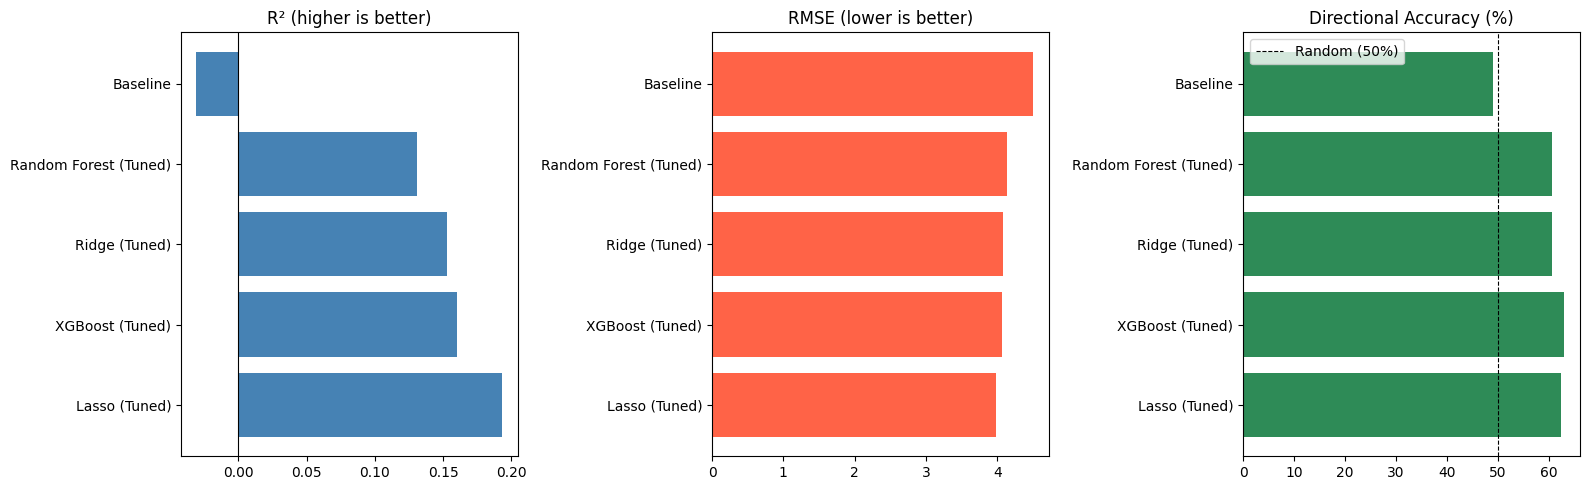

In [27]:
# ── FINAL MODEL COMPARISON CHART ──────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].barh(results_df.index, results_df['R²'], color='steelblue')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('R² (higher is better)')

axes[1].barh(results_df.index, results_df['RMSE'], color='tomato')
axes[1].set_title('RMSE (lower is better)')

axes[2].barh(results_df.index, results_df['Dir Acc'], color='seagreen')
axes[2].axvline(50, color='black', linewidth=0.8, linestyle='--', label='Random (50%)')
axes[2].set_title('Directional Accuracy (%)')
axes[2].legend()

plt.tight_layout()
plt.show()

In [29]:
import joblib

In [30]:
joblib.dump(scaler, 
            r'C:\Users\boser\Desktop\Project_Carbon\models\scaler.pkl')

print("Scaler saved.")

Scaler saved.


In [31]:
# Save the tuned XGBoost model
joblib.dump(xgb_random.best_estimator_, 
            r'C:\Users\boser\Desktop\Project_Carbon\models\xgb_tuned.pkl')

print("Model saved.")
print(f"Best XGBoost parameters:")
for k, v in xgb_random.best_params_.items():
    print(f"  {k}: {v}")

Model saved.
Best XGBoost parameters:
  subsample: 0.9
  reg_lambda: 1.0
  reg_alpha: 2.0
  n_estimators: 400
  min_child_weight: 3
  max_depth: 3
  learning_rate: 0.005
  gamma: 1.0
  colsample_bytree: 0.7
